In [84]:
import matplotlib.pyplot as plt
import numpy as np

# pre interacktivny 3D graf odkometujte
# %matplotlib widget

Vygenerujeme náhodný povrch pomocou filtrovania bieleho šumu (môžte preskočiť)

In [85]:
rng = np.random.default_rng()

N = 50
d = 1/N

k_max = 1/(2*d)

XX, YY = np.meshgrid(np.linspace(0, 1, N), np.linspace(0, 1, N))
_Z = rng.standard_normal(XX.shape)
_z_fft = np.fft.fft2(_Z)
_ks = np.fft.fftfreq(N, d)
KSx, KSy = np.meshgrid(_ks, _ks)
K = np.sqrt(KSx**2 + KSy**2)
_z_fft[K > k_max / 20] = 0 # vysoke frekvencie zmazeme
Z = np.fft.ifft2(_z_fft).real

Vykreslime povrch a gradient $$ \nabla V(x, y) =  \left(\frac{\partial V}{\partial x}, \frac{\partial V}{\partial y} \right) $$

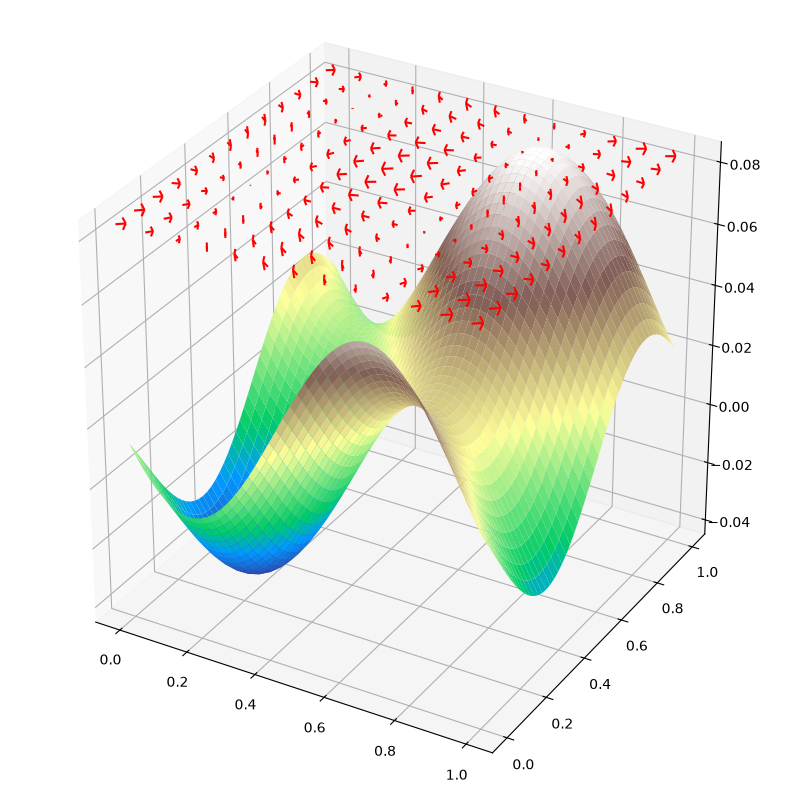

In [86]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection="3d")
ax.set_aspect("equal")

ax.plot_surface(XX, YY, Z, cmap="terrain", edgecolor="none")

K = 4
dZx, dZy = np.gradient(-Z, d, d, axis=(1, 0))
ax.quiver(XX[::K, ::K], YY[::K, ::K], np.ones_like(XX)[::K, ::K]*Z.max(), dZx[::K, ::K], dZy[::K, ::K], 0, length=0.1, 
          color='r', pivot='middle')